# 基于AlexNet的花朵分类实验

本notebook将完整实现基于AlexNet网络的花朵图像分类任务，包括：
- AlexNet网络模型介绍
- 数据集介绍与获取
- 数据预处理与划分
- 模型训练与评估
- Loss曲线分析
- 预测测试

---

## 1. AlexNet模型介绍

**AlexNet** 是深度学习历史上的里程碑式模型，由Alex Krizhevsky等人在2012年提出，在ImageNet图像分类竞赛中取得了突破性成果，标志着深度学习时代的开启。

### 模型架构特点：
1. **5层卷积层 + 3层全连接层**的深度架构
2. **ReLU激活函数**：首次在CNN中大规模使用，解决梯度消失问题
3. **局部响应归一化（LRN）**：增强模型泛化能力
4. **Dropout技术**：在全连接层使用，防止过拟合
5. **数据增强**：随机裁剪、翻转等技术提升模型鲁棒性
6. **GPU并行训练**：首次利用双GPU加速训练

### 网络结构：
- **输入**：224×224×3 的RGB图像
- **Conv1**：96个11×11卷积核，步长4
- **Conv2**：256个5×5卷积核
- **Conv3**：384个3×3卷积核
- **Conv4**：384个3×3卷积核
- **Conv5**：256个3×3卷积核
- **FC1**：4096个神经元
- **FC2**：4096个神经元
- **FC3**：输出层（本实验为5个类别）

---

import subprocess
import sys
import os

# 解决OpenMP重复初始化问题
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# 确保tqdm已安装
try:
    from tqdm import tqdm
except ImportError:
    print("正在安装tqdm...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "-q", "-i", 
                          "https://pypi.tuna.tsinghua.edu.cn/simple"])
    from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")

## 3. 导入必要的库

In [1]:
# 确保torch已安装
import subprocess
import sys

try:
    import torch
    print(f"✓ PyTorch已安装 - 版本: {torch.__version__}")
except ImportError:
    print("正在安装PyTorch，请稍候...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-i", 
                          "https://pypi.tuna.tsinghua.edu.cn/simple", 
                          "torch", "torchvision", "torchsummary", "-q"])
    print("✓ PyTorch安装完成")

import sys
print(f"\nPython解释器: {sys.executable}")
print(f"Python版本: {sys.version}")

✓ PyTorch已安装 - 版本: 2.10.0+cpu

Python解释器: d:\Anaconda\envs\iris_env\python.exe
Python版本: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


In [ ]:
import subprocess
import sys
import os

# 解决OpenMP重复初始化问题（降低Kernel崩溃概率）
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# 确保tqdm已安装
try:
    from tqdm import tqdm
except ImportError:
    print("正在安装tqdm...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "-q", "-i", 
                          "https://pypi.tuna.tsinghua.edu.cn/simple"])
    from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from pathlib import Path
import time

# 设置中文字体（按可用字体自动选择）
preferred_fonts = [
    'Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC',
    'PingFang SC', 'WenQuanYi Zen Hei'
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in preferred_fonts:
    if font in available_fonts:
        plt.rcParams['font.sans-serif'] = [font]
        break
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")

PyTorch版本: 2.10.0+cpu
CUDA是否可用: False


## 4. 设置超参数和数据路径

In [6]:
# 超参数设置
batch_size = 32
learning_rate = 0.001
num_epochs = 10
num_classes = 5  # 五种花朵类型

# 数据路径
data_dir = Path(r'd:\anlixinagmu\Alexnet 16\flower_data\flower_data')
train_dir = data_dir / 'train'
val_dir = data_dir / 'val'

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


## 5. 数据预处理和数据加载器

In [7]:
# 数据增强和预处理
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 加载数据集
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"类别: {train_dataset.classes}")

训练集大小: 3306
验证集大小: 364
类别: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## 6. 定义AlexNet模型

In [8]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=5):
        super(AlexNet, self).__init__()
        
        # 特征提取层
        self.features = nn.Sequential(
            # Conv1: 224x224x3 -> 55x55x96
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            # Conv2: 27x27x96 -> 27x27x256
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            # Conv3: 13x13x256 -> 13x13x384
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            # Conv4: 13x13x384 -> 13x13x384
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            # Conv5: 13x13x384 -> 13x13x256
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# 创建模型实例
model = AlexNet(num_classes=num_classes).to(device)
print("模型结构:")
print(model)
print(f"\n总参数量: {sum(p.numel() for p in model.parameters())}")

模型结构:
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p

### 6.1 可视化网络结构

In [6]:
# 如果还未安装torchsummary，请先运行此单元格
# !pip install torchsummary

## 7. 定义损失函数和优化器

In [9]:
# 损失函数
criterion = nn.CrossEntropyLoss()

# 优化器
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 学习率调度器
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(f"优化器: Adam, 学习率: {learning_rate}")
print(f"损失函数: CrossEntropyLoss")

优化器: Adam, 学习率: 0.001
损失函数: CrossEntropyLoss


## 8. 训练和验证函数

In [10]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 使用tqdm添加进度条
    progress_bar = tqdm(train_loader, desc="训练中", unit="batch", leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播和优化
        loss.backward()
        optimizer.step()
        
        # 统计
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # 更新进度条显示当前loss和准确率
        current_acc = 100. * correct / total
        progress_bar.set_postfix({'Loss': f'{running_loss/(progress_bar.n+1):.4f}', 
                                  'Acc': f'{current_acc:.2f}%'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """验证模型"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 验证过程也添加进度条
    progress_bar = tqdm(val_loader, desc="验证中", unit="batch", leave=False)
    
    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # 更新进度条
            current_acc = 100. * correct / total
            progress_bar.set_postfix({'Loss': f'{running_loss/(progress_bar.n+1):.4f}', 
                                      'Acc': f'{current_acc:.2f}%'})
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

print("训练和验证函数已定义（包含进度条）")

训练和验证函数已定义（包含进度条）


## 9. 开始训练模型

In [9]:
# 记录训练历史
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
start_time = time.time()

print("\n" + "="*80)
print("开始训练AlexNet模型")
print("="*80)
print(f"总训练轮数: {num_epochs}")
print(f"批次大小: {batch_size}")
print(f"学习率: {learning_rate}")
print(f"优化器: Adam")
print(f"设备: {device}")
print("="*80 + "\n")

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # 打印当前训练轮数
    print(f"\n{'='*80}")
    print(f"第 [{epoch+1}/{num_epochs}] 轮训练")
    print(f"{'='*80}")
    
    # 训练
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # 验证
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # 更新学习率
    scheduler.step()
    
    # 记录历史
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_alexnet_model.pth')
        best_mark = " ⭐ (最佳模型)"
    else:
        best_mark = ""
    
    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]
    
    # 打印详细的训练日志
    print(f"\n📊 第 [{epoch+1}/{num_epochs}] 轮完成")
    print(f"   ⏱️  耗时: {epoch_time:.2f}s")
    print(f"   📈 训练指标")
    print(f"      └─ Loss: {train_loss:.4f}")
    print(f"      └─ Accuracy: {train_acc:.2f}%")
    print(f"   📉 验证指标{best_mark}")
    print(f"      └─ Loss: {val_loss:.4f}")
    print(f"      └─ Accuracy: {val_acc:.2f}%")
    print(f"   🔧 学习率: {current_lr:.6f}")

print("\n" + "="*80)
total_time = time.time() - start_time
print(f"✅ 训练完成!")
print(f"   总用时: {total_time/60:.2f}分钟 ({total_time:.0f}秒)")
print(f"   最佳验证准确率: {best_val_acc:.2f}%")
print("="*80)

# 保存训练历史到文件，防止kernel崩溃导致数据丢失
import json
with open('training_history.json', 'w') as f:
    json.dump(history, f)
print("\n✓ 训练历史已保存到 training_history.json")


开始训练AlexNet模型
总训练轮数: 10
批次大小: 32
学习率: 0.001
优化器: Adam
设备: cpu


第 [1/10] 轮训练



📊 第 [1/10] 轮完成
   ⏱️  耗时: 143.37s
   📈 训练指标
      └─ Loss: 1.7990
      └─ Accuracy: 27.34%
   📉 验证指标 ⭐ (最佳模型)
      └─ Loss: 1.5152
      └─ Accuracy: 38.74%
   🔧 学习率: 0.001000

第 [2/10] 轮训练



📊 第 [2/10] 轮完成
   ⏱️  耗时: 146.09s
   📈 训练指标
      └─ Loss: 1.2889
      └─ Accuracy: 43.86%
   📉 验证指标 ⭐ (最佳模型)
      └─ Loss: 1.2824
      └─ Accuracy: 42.86%
   🔧 学习率: 0.001000

第 [3/10] 轮训练



📊 第 [3/10] 轮完成
   ⏱️  耗时: 145.22s
   📈 训练指标
      └─ Loss: 1.2084
      └─ Accuracy: 46.07%
   📉 验证指标 ⭐ (最佳模型)
      └─ Loss: 1.2245
      └─ Accuracy: 47.53%
   🔧 学习率: 0.001000

第 [4/10] 轮训练



📊 第 [4/10] 轮完成
   ⏱️  耗时: 158.77s
   📈 训练指标
      └─ Loss: 1.1623
      └─ Accuracy: 50.67%
   📉 验证指标
      └─ Loss: 1.2484
      └─ Accuracy: 47.53%
   🔧 学习率: 0.001000

第 [5/10] 轮训练


...


📊 第 [6/10] 轮完成
   ⏱️  耗时: 172.43s
   📈 训练指标
      └─ Loss: 1.1518
      └─ Accuracy: 52.12%
   📉 验证指标 ⭐ (最佳模型)
      └─ Loss: 1.1756
      └─ Accuracy: 51.92%
   🔧 学习率: 0.001000

第 [7/10] 轮训练



📊 第 [7/10] 轮完成
   ⏱️  耗时: 165.09s
   📈 训练指标
      └─ Loss: 1.1533
      └─ Accuracy: 51.33%
   📉 验证指标
      └─ Loss: 1.1250
      └─ Accuracy: 51.65%
   🔧 学习率: 0.000100

第 [8/10] 轮训练



📊 第 [8/10] 轮完成
   ⏱️  耗时: 170.95s
   📈 训练指标
      └─ Loss: 1.0235
      └─ Accuracy: 58.38%
   📉 验证指标 ⭐ (最佳模型)
      └─ Loss: 1.0457
      └─ Accuracy: 59.62%
   🔧 学习率: 0.000100

第 [9/10] 轮训练



📊 第 [9/10] 轮完成
   ⏱️  耗时: 171.28s
   📈 训练指标
      └─ Loss: 0.9820
      └─ Accuracy: 60.01%
   📉 验证指标
      └─ Loss: 1.0577
      └─ Accuracy: 57.97%
   🔧 学习率: 0.000100

第 [10/10] 轮训练



📊 第 [10/10] 轮完成
   ⏱️  耗时: 169.53s
   📈 训练指标
      └─ Loss: 0.9776
      └─ Accuracy: 60.62%
   📉 验证指标
      └─ Loss: 1.0443
      └─ Accuracy: 58.24%
   🔧 学习率: 0.000100

✅ 训练完成!
   总用时: 26.80分钟 (1608秒)
   最佳验证准确率: 59.62%

✓ 训练历史已保存到 training_history.json


## 10. 绘制训练曲线

从文件加载训练历史...
✓ 成功加载历史数据 (10 epochs)


C:\Users\32077\AppData\Local\Temp\ipykernel_26384\3382836085.py:40: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_26384\3382836085.py:40: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_26384\3382836085.py:40: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_26384\3382836085.py:40: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_26384\3382836085.py:40: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_26384\3382836085.py:40: UserWarning: Glyph 25439 (\

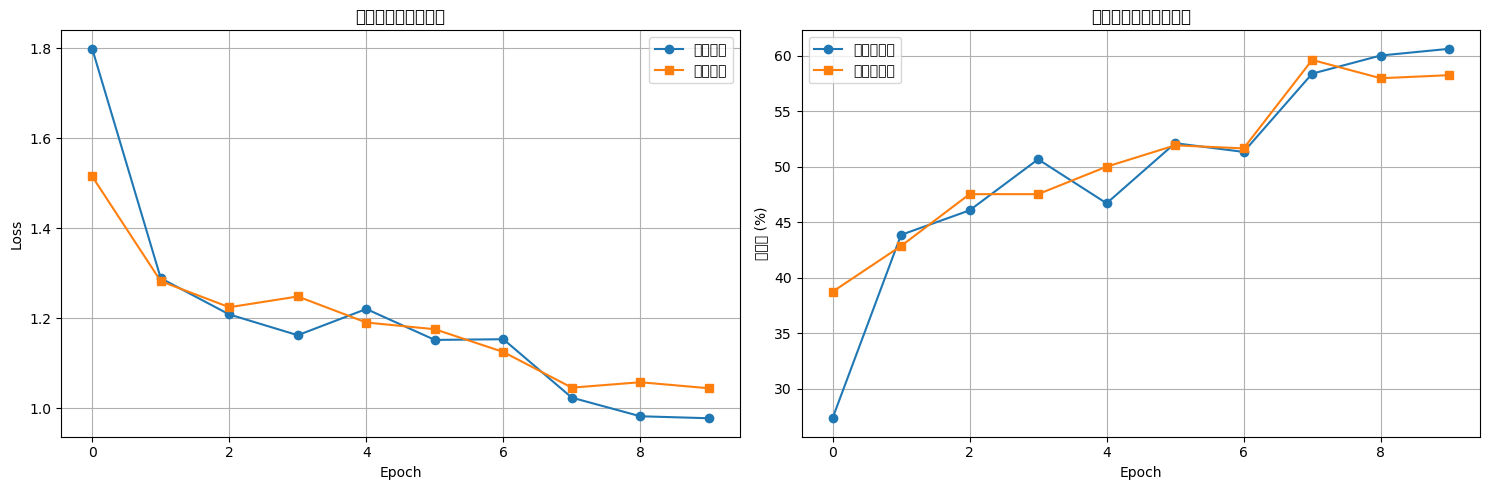

✓ 训练曲线已保存为 training_curves.png


In [1]:
# 如果history不在内存中，尝试从文件加载
import json
import os

if 'plt' not in globals():
    import matplotlib.pyplot as plt

if 'history' not in locals():
    if os.path.exists('training_history.json'):
        print("从文件加载训练历史...")
        with open('training_history.json', 'r') as f:
            history = json.load(f)
        print(f"✓ 成功加载历史数据 ({len(history['train_loss'])} epochs)")
    else:
        print("❌ 找不到历史数据，请先运行第9章的训练代码")
        history = None

if history is not None:
    try:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # 绘制损失曲线
        ax1.plot(history['train_loss'], label='训练损失', marker='o')
        ax1.plot(history['val_loss'], label='验证损失', marker='s')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('训练和验证损失曲线')
        ax1.legend()
        ax1.grid(True)

        # 绘制准确率曲线
        ax2.plot(history['train_acc'], label='训练准确率', marker='o')
        ax2.plot(history['val_acc'], label='验证准确率', marker='s')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('准确率 (%)')
        ax2.set_title('训练和验证准确率曲线')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("✓ 训练曲线已保存为 training_curves.png")
    except Exception as e:
        print(f"❌ 绘制失败: {e}")
else:
    print("跳过绘制，等待训练完成...")

## 11. 加载最佳模型并评估

In [11]:
# 加载最佳模型并评估（带兜底检查）
import os

if 'model' not in locals():
    if 'AlexNet' in globals() and 'num_classes' in locals() and 'device' in locals():
        model = AlexNet(num_classes=num_classes).to(device)
    else:
        raise NameError("未找到模型定义，请先运行第6章（模型定义）和第4章（超参数/设备）")

if not os.path.exists('best_alexnet_model.pth'):
    raise FileNotFoundError("未找到 best_alexnet_model.pth，请先运行第9章训练")

model.load_state_dict(torch.load('best_alexnet_model.pth', map_location=device))
print("已加载最佳模型")

if 'criterion' not in locals() or 'val_loader' not in locals() or 'device' not in locals():
    raise NameError("缺少验证所需变量，请先运行第5章（数据加载）和第7章（损失函数）")

# 在验证集上评估
val_loss, val_acc = validate(model, val_loader, criterion, device)
print(f"\n最佳模型在验证集上的表现:")
print(f"  Loss: {val_loss:.4f}")
print(f"  Accuracy: {val_acc:.2f}%")

已加载最佳模型



最佳模型在验证集上的表现:
  Loss: 1.0457
  Accuracy: 59.62%


## 12. 可视化预测结果

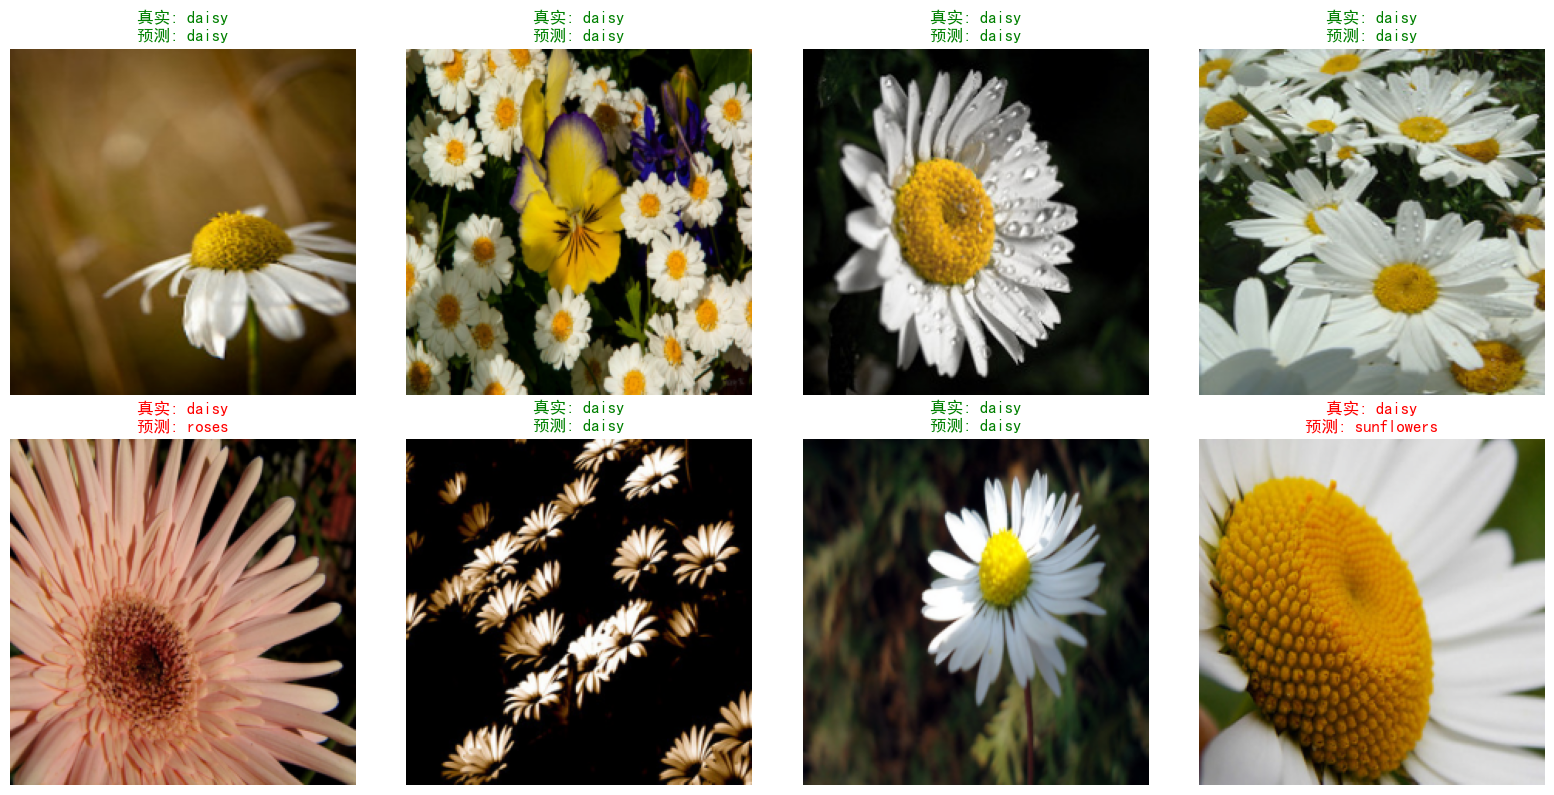

预测结果已保存为 predictions.png


In [12]:
def imshow(img):
    """显示图像"""
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img


# 获取一批验证数据
dataiter = iter(val_loader)
images, labels = next(dataiter)

# 预测
model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

# 显示图像和预测结果
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
class_names = train_dataset.classes

for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        ax.imshow(imshow(images[idx]))
        true_label = class_names[labels[idx]]
        pred_label = class_names[predicted[idx].cpu()]
        color = 'green' if labels[idx] == predicted[idx].cpu() else 'red'
        ax.set_title(f'真实: {true_label}\n预测: {pred_label}', color=color, fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("预测结果已保存为 predictions.png")

## 13. 计算混淆矩阵

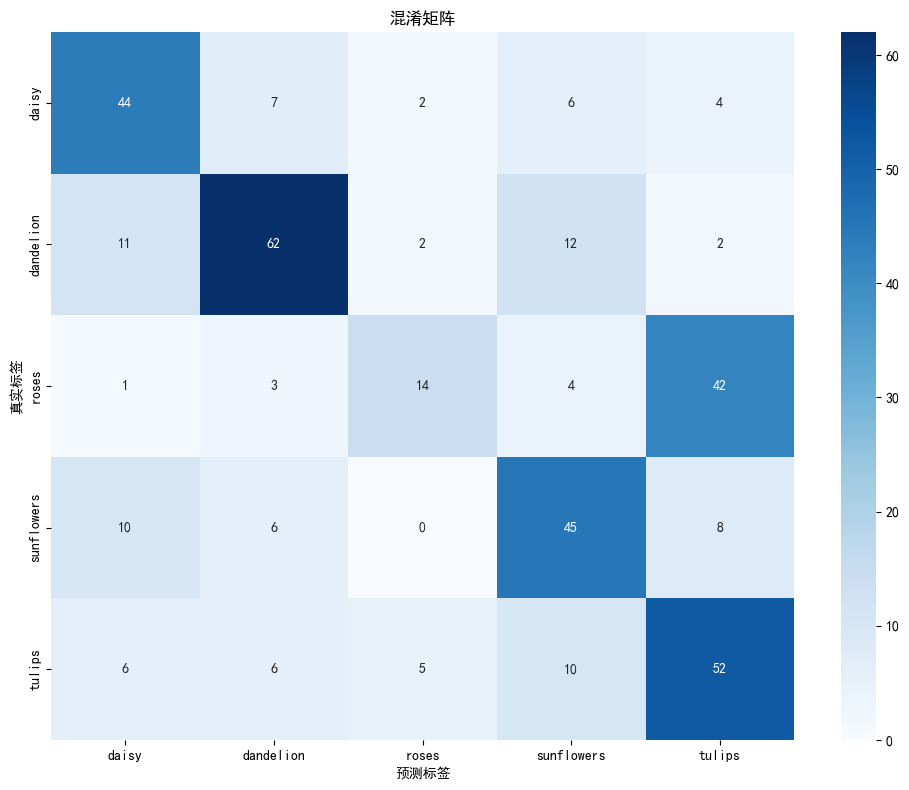


分类报告:
              precision    recall  f1-score   support

       daisy       0.61      0.70      0.65        63
   dandelion       0.74      0.70      0.72        89
       roses       0.61      0.22      0.32        64
  sunflowers       0.58      0.65      0.62        69
      tulips       0.48      0.66      0.56        79

    accuracy                           0.60       364
   macro avg       0.60      0.58      0.57       364
weighted avg       0.61      0.60      0.58       364



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 收集所有预测结果
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 计算混淆矩阵
cm = confusion_matrix(all_labels, all_preds)

# 绘制混淆矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('混淆矩阵')
plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印分类报告
print("\n分类报告:")
print(classification_report(all_labels, all_preds, target_names=class_names))

## 14. 总结

本实验完成了基于AlexNet的花卉图像分类任务，主要内容包括：

1. **数据准备**：使用了包含5类花卉（雏菊、蒲公英、玫瑰、向日葵、郁金香）的数据集
2. **模型构建**：实现了经典的AlexNet网络架构
3. **训练过程**：使用Adam优化器和CrossEntropyLoss损失函数进行训练
4. **结果可视化**：绘制了训练曲线、预测结果和混淆矩阵

### 模型特点
- 5层卷积层 + 3层全连接层
- 使用ReLU激活函数
- 使用Dropout防止过拟合
- 输入图像大小: 224x224

